In [1]:
# https://drive.google.com/file/d/10cyq2pvGMaHnCXR0rolTUwQ8TgsHKiEC/view?usp=sharing ?

#!gdown --id 10cyq2pvGMaHnCXR0rolTUwQ8TgsHKiEC -O vp.jpg


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib notebook

img = cv2.imread('vp.jpg')
# cv2_imshow(img)

In [3]:
def norm_points(p):
    r,c = p.shape
    for i in range(c):
        if p[-1,i] != 0:
            p[:,i] /= p[-1,i]
    return p

Definimos los puntos ideales de la reticula

In [4]:
#un cuadrado de 1x1

pr = np.ones((3,4))
#pr[:2,0] = [0., 5.]
#pr[:2,1] = [0., 0.]
#pr[:2,2] = [2.8, 0.]
#pr[:2,3] = [2.8, 5.]
pr[:2,0] = [0., 1]
pr[:2,1] = [0., 0.]
pr[:2,2] = [1, 0.]
pr[:2,3] = [1, 1.]

pr = norm_points(pr)

print("pr =\n", pr)

#Estas son las lineas de la reticula que pasan por los puntos pr.
lr = np.ones((3,4))
lr[:,0] = np.cross(pr[:,0], pr[:,1])
lr[:,1] = np.cross(pr[:,1], pr[:,2])
lr[:,2] = np.cross(pr[:,2], pr[:,3])
lr[:,3] = np.cross(pr[:,3], pr[:,0])


print("lr =\n", lr)

pr =
 [[0. 0. 1. 1.]
 [1. 0. 0. 1.]
 [1. 1. 1. 1.]]
lr =
 [[ 1.  0. -1.  0.]
 [ 0.  1.  0. -1.]
 [ 0.  0.  1.  1.]]


Definir puntos de fuga y puntos reales

In [5]:

# Definir puntos de fuga y puntos
vp1 = np.array([-3, 540, 1])
vp2 = np.array([1916, 540, 1])

p1 = np.array([114, 766, 1])
p2 = np.array([829, 677, 1])
p3 = np.array([1048, 716, 1])

blue_points = [p1, p2, p3]

# Calcular líneas
l = np.zeros((3, 4))
l[:, 0] = np.cross(vp1, p2)
l[:, 1] = np.cross(vp1, p1)
l[:, 2] = np.cross(vp2, p1)
l[:, 3] = np.cross(vp2, p3)

def norm_points(p):
    return p / p[-1]

# Calcular punto de intersección p4
p4 = np.cross(l[:, 1], l[:, 3])
p4 = norm_points(p4)

# Almacenar puntos en la matriz p
p = np.zeros((3, 4))
p[:, 0] = p1
p[:, 1] = p2
p[:, 2] = p3
p[:, 3] = p4
p = norm_points(p)

# Dibujar puntos de fuga (rojo)
cv2.circle(img, (vp1[0], vp1[1]), 5, (0, 0, 255), -1)
cv2.circle(img, (vp2[0], vp2[1]), 5, (0, 0, 255), -1)

# Dibujar puntos azules
for i, point in enumerate(blue_points):
    cv2.circle(img, (point[0], point[1]), 5, (255, 0, 0), -1)
    cv2.putText(img, f'p{i+1}', (point[0] + 10, point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

cv2.circle(img, (int(p4[0]), int(p4[1])), 5, (0, 255, 255), -1)  # Dibujar p4 (amarillo)
cv2.putText(img, 'p4', (int(p4[0]) + 10, int(p4[1]) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

# Función para calcular intersección de una línea con los bordes de la imagen
def get_line_endpoints(line, width, height):
    x0, y0, w0 = np.cross(line, [1, 0, 0])  # Intersección con x=0
    x1, y1, w1 = np.cross(line, [1, 0, -width])  # Intersección con x=width
    y0, x0 = y0 / w0, x0 / w0
    y1, x1 = y1 / w1, x1 / w1
    return (int(x0), int(y0)), (int(x1), int(y1))

# Dibujar líneas
for i in range(4):
    pt1, pt2 = get_line_endpoints(l[:, i], img.shape[1], img.shape[0])
    color = (0, 255, 0)
    cv2.line(img, pt1, pt2, color, 2)
    mid_x, mid_y = (pt1[0] + pt2[0]) // 2, (pt1[1] + pt2[1]) // 2
    cv2.putText(img, f'l{i+1}', (mid_x, mid_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)




Compute the transformation that maps the projective space into and affine one.

In [6]:
def proj2Affine(Vp1, Vp2):
  """
  This function defines a homography that maps the points that lie on the line
  defined by the homogeneous 2D points Vp1 and Vp2 to a line at the infinity

  Parameters:

  Vp1, Vp2: 3x1 matrices, that represents homogenous 2D points.

  Returns a 3x3 matrix that represents the mapping homography.

  First we compute the equation of the line where Vp1 and Vp2 lies.
  """
  m = np.array([[Vp1[0], Vp1[1]], [Vp2[0], Vp2[1]]])
  b = np.array([-1, -1])
  l = np.ones(3)
  l[:2] = np.linalg.solve(m, b)
  # Define H according to formula in Hartley & Zisserman "Multiple View Geometry"
  # 2nd edition, section 2.7.2, pp 49
  H = np.eye(3)
  H[2, :] = l.T
  return H

In [7]:
H = proj2Affine(vp1, vp2)
H

array([[ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  1.        ,  0.        ],
       [ 0.        , -0.00185185,  1.        ]])

The mapping that maps lines is defined in terms of the mapping of points.


In [8]:
Hl = np.linalg.inv(H).T
Hl

array([[1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.00185185],
       [0.        , 0.        , 1.        ]])

% The computed lines are mapped into the affine space.


In [9]:
lp = np.dot(Hl, l)
#lp = norm_points(lp)
print(lp.shape)
print(np.dot(lp[:,0],lp[:,1])/(np.linalg.norm(lp[:,0])*np.linalg.norm(lp[:,1])))

print(np.dot(lp[:,2],lp[:,3])/(np.linalg.norm(lp[:,2])*np.linalg.norm(lp[:,3])))


print(np.dot(lp[:,1],lp[:,2])/(np.linalg.norm(lp[:,1])*np.linalg.norm(lp[:,2])))

print(np.dot(lp[:,0],lp[:,3])/(np.linalg.norm(lp[:,0])*np.linalg.norm(lp[:,3])))

print(lp[:,0])
print(lp[:,1])
print(lp[:,2])
print(lp[:,3])

(3, 4)
0.9999947690615424
0.9999999774170448
-0.9999930040931201
-0.999999564337273
[-1.37000000e+02 -7.61111111e-01 -4.49691000e+05]
[-2.26000000e+02 -1.25555556e+00 -6.38580000e+04]
[-2.26000000e+02  8.01881481e+02  1.40609600e+06]
[-1.76000000e+02  6.24474074e+02  8.05936000e+05]


The points that intersect the lines in the affine space are compute and normalized.

In [10]:
pp = np.ones((3, 4))
pp[:, 0] = np.cross(lp[:, 1], lp[:, 2])
pp[:, 1] = np.cross(lp[:, 0], lp[:, 2])
pp[:, 2] = np.cross(lp[:, 0], lp[:, 3])
pp[:, 3] = np.cross(lp[:, 1], lp[:, 3])

pp = norm_points(pp)

pp

array([[-2.72389381e+02, -3.26755820e+03, -3.27012591e+03,
        -2.74957096e+02],
       [-1.83026549e+03, -2.67441536e+03, -2.21222660e+03,
        -1.36807673e+03],
       [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00]])

<IPython.core.display.Javascript object>


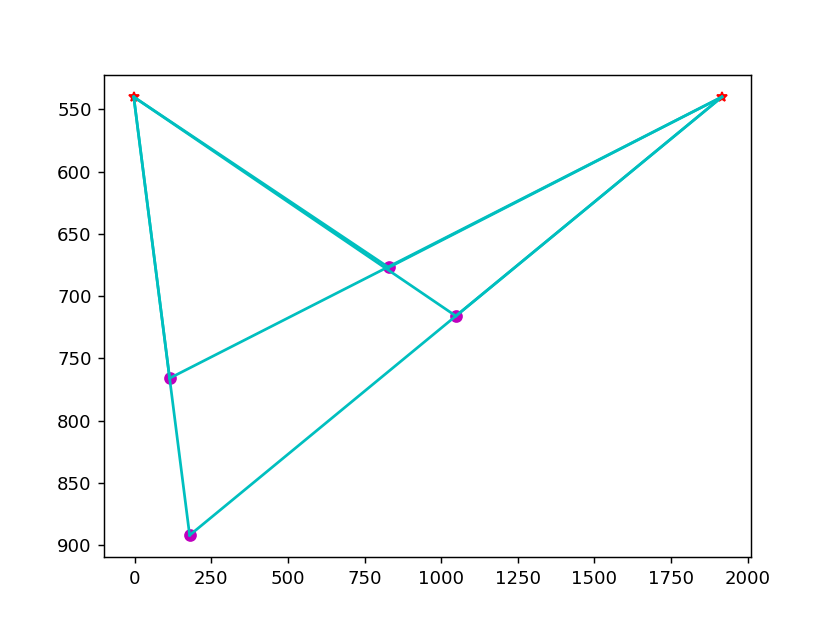

In [11]:
fig1,ax1 = plt.subplots()
ax1.plot(vp1[0],vp1[1],"r*",vp2[0],vp2[1],"r*")
ax1.plot(p[0,0],p[1,0],'om',p[0,1],p[1,1],'om',p[0,2],p[1,2],'om',p[0,3],p[1,3],'om')
ax1.plot(np.array([vp1[0], p[0,0]]), np.array([vp1[1], p[1,0]]),'c')
ax1.plot(np.array([vp1[0], p[0,1]]), np.array([vp1[1], p[1,1]]),'c')
ax1.plot(np.array([vp2[0], p[0,1]]), np.array([vp2[1], p[1,1]]),'c')
ax1.plot(np.array([vp2[0], p[0,2]]), np.array([vp2[1], p[1,2]]),'c')
ax1.plot(np.array([vp1[0], p[0,3]]), np.array([vp1[1], p[1,3]]),'c')
ax1.plot(np.array([vp1[0], p[0,2]]), np.array([vp1[1], p[1,2]]),'c')
ax1.plot(np.array([vp2[0], p[0,0]]), np.array([vp2[1], p[1,0]]),'c')
ax1.plot(np.array([vp2[0], p[0,3]]), np.array([vp2[1], p[1,3]]),'c')
ax1.invert_yaxis()

<IPython.core.display.Javascript object>


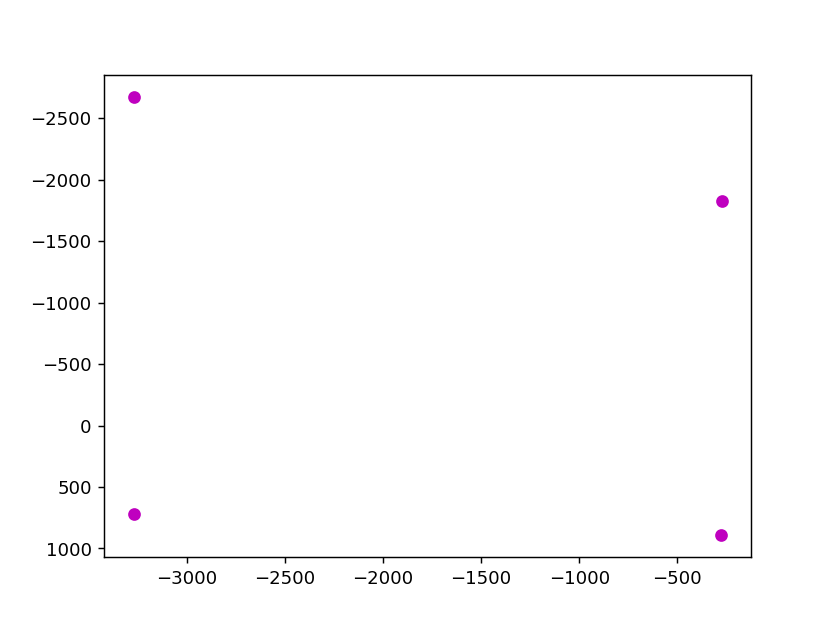

In [12]:
fig2,ax2 = plt.subplots()

ax2.plot(pp[0,0],pp[1,0],'om',pp[0,1],pp[1,1],'om',pp[0,2],p[1,2],'om',pp[0,3],p[1,3],'om')

ax2.invert_yaxis()

Homography Matrix:
[[ 1.94002150e+00 -7.60783183e+02  8.29000000e+02]
 [-1.09296703e+02 -2.18630858e+02  6.77000000e+02]
 [-2.07118300e-01 -4.01606864e-01  1.00000000e+00]]


<IPython.core.display.Javascript object>


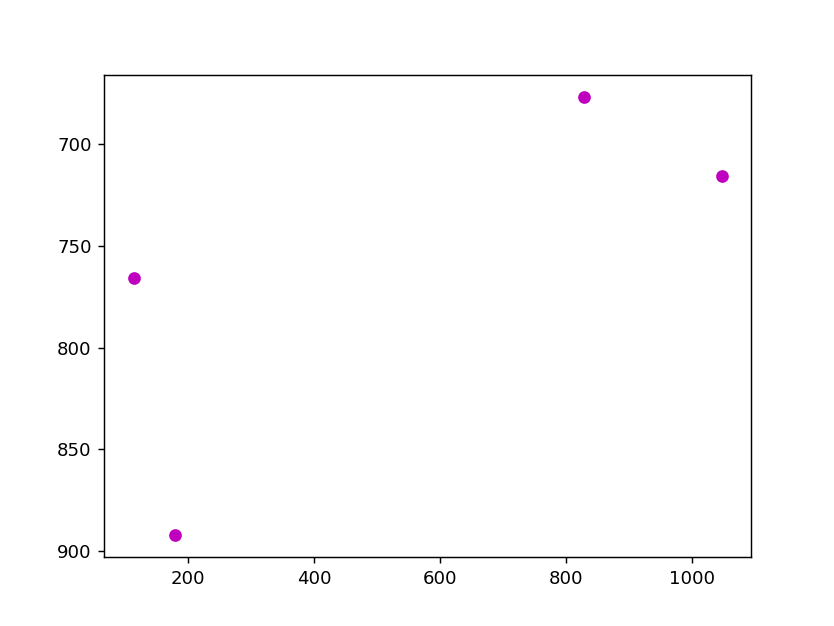

(array([[1.14000000e+02, 8.29000000e+02, 1.04800000e+03, 1.79303223e+02],
        [7.66000000e+02, 6.77000000e+02, 7.16000000e+02, 8.92141296e+02],
        [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00]]),
 array([[-1.59545099e-04,  3.36404099e-04, -2.18379637e-04,
          3.53910351e-03],
        [-1.28173872e-03, -1.88903840e-03, -1.07700858e-03,
         -1.83219034e-03],
        [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
          1.00000000e+00]]))

In [13]:
# Define the source and destination points for the homography
src_pts = np.float32([pr[:, 0], pr[:, 1], pr[:, 2], pr[:, 3]])
dst_pts = np.float32([p[:, 0], p[:, 1], p[:, 2], p[:, 3]])


# Find the homography matrix
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)

# Print the homography matrix
print("Homography Matrix:")
print(M)

pm = np.dot(M, pr)
pm = norm_points(pm)

lm = np.dot (np.linalg.inv(M.T), lr)
lm = norm_points(lm)



fig3,ax3 = plt.subplots()

ax3.plot(pm[0,0],pm[1,0],'om',pm[0,1],pm[1,1],'om',pm[0,2],pm[1,2],'om',pm[0,3],pm[1,3],'om')

ax3.invert_yaxis()

pm,lm

In [14]:
for i in range(4):
    point = [int(np.round(pm[0,i])), int(np.round(pm[1,i]))]
    cv2.circle(img, (point[0], point[1]), 8, (255, 0, 255), -1)
    cv2.putText(img, f'p{i+1}', (point[0] + 10, point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)


# Mostrar la imagen
cv2.namedWindow("Ventana1", cv2.WINDOW_NORMAL)
cv2.imshow("Ventana1",img)
cv2.waitKey(0)


QSettings::value: Empty key passed
QSettings::value: Empty key passed


13

In [15]:
cv2.destroyAllWindows()

In [16]:
def def_grid_lines(r0,r1,c0,c1,w,h):
    R=np.linspace(r0,r1,r1-r0+1)
    C=np.linspace(c0,c1,c1-c0+1)
    n = len(R)+len(C)
    l=np.zeros((3, n))
    
    #Definimos primero lineas horizontales
    idx=0
    for i in R:
        l[:,idx]=[0, 1, h*i]
        idx +=1
        
    #Definimos primero lineas verticales
    for i in C:
        l[:,idx]=[1, 0, h*i]
        idx=idx+1
    return l

In [17]:
img = cv2.imread('vp.jpg')

lines = def_grid_lines(-6,6,-6,6,1,1)  # Forma (3, N_líneas)

# 4. Calcular la Homografía para Líneas (H_l)
Hl = np.linalg.inv(M).T  # M = H_p

# 5. Proyectar las Líneas a la Imagen
projected_lines = np.dot(Hl, lines)
projected_lines = projected_lines / np.linalg.norm(projected_lines, axis=0)  # Normalizar

# # Dibujar puntos proyectados
# for i in range(projected_pts.shape[1]):
#     x, y = int(projected_pts[0, i]), int(projected_pts[1, i])
#     cv2.circle(img, (x, y), 5, (0, 255, 0), -1)

# Dibujar líneas proyectadas
for i in range(projected_lines.shape[1]):
    a, b, c = projected_lines[:, i]
    # Encontrar dos puntos en la línea (para dibujar)
    x0, y0 = 0, int(-c/b) if b != 0 else 0
    x1, y1 = img.shape[1], int((-c - a*img.shape[1])/b) if b != 0 else 0
    cv2.line(img, (x0, y0), (x1, y1), (255, 0, 0), 2)

cv2.namedWindow("Projected Grid", cv2.WINDOW_NORMAL)
cv2.imshow("Projected Grid", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

prolonga las lineas hasta los bordes de la imagen

In [18]:
def get_line_endpoints(line, width, height):
    x1, y1, x2, y2 = line
    line_params = np.polyfit([x1, x2], [y1, y2], 1)
    slope, intercept = line_params

    points = []
    for x in [0, width]:
        y = slope * x + intercept
        if 0 <= y <= height:
            points.append((int(x), int(y)))

    for y in [0, height]:
        x = (y - intercept) / slope
        if 0 <= x <= width:
            points.append((int(x), int(y)))

    if len(points) >= 2:
        return points[0], points[1]
    else:
        return (x1, y1), (x2, y2)

carga todas las lineas guardadas en el archivo lines_near_vps.npy

In [19]:
img = cv2.imread('vp.jpg')

lines_near_vps_no_merged = np.load('lines_near_vps.npy')
lines_near_vps = np.load('merged_lines_near_vps.npy')
#print(lines_near_vps_no_merged.shape, lines_near_vps.shape)
#print(lines_near_vps)


# for line in lines_near_vps_no_merged:
#     x1, y1, x2, y2 = line[0]
#     pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
#     cv2.line(img, pt1, pt2, (0, 0, 255), 1)

# Iterate over each line and draw it on the image
for line in lines_near_vps:
    x1, y1, x2, y2 = line[0]

    pt1 = x1, y1
    pt2 = x2, y2
    # pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (0, 255, 0), 3)  # Green color and line thickness of 2


# Mostrar la imagen con las líneas dibujadas
cv2.namedWindow("Image with Lines", cv2.WINDOW_NORMAL)
cv2.imshow('Image with Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [20]:
lines_near_vps_no_merged

array([[[ 112,  760,  830,  672]],

       [[ 291,  851,  830,  747]],

       [[1314,  875, 1472,  788]],

       [[1580,  604, 1636,  593]],

       [[1389,  575, 1476,  569]],

       [[1479,  750, 1642,  671]],

       [[1265,  852, 1411,  783]],

       [[1467,  789, 1674,  674]],

       [[1519,  621, 1725,  578]],

       [[1734,  626, 1915,  541]],

       [[1129,  690, 1347,  648]],

       [[1750,  633, 1914,  539]],

       [[1641,  593, 1729,  575]],

       [[1289,  668, 1371,  651]],

       [[ 171,  760,  829,  679]],

       [[ 521,  822,  830,  761]],

       [[ 357,  855,  666,  794]],

       [[ 716,  783,  969,  733]],

       [[1168,  683, 1358,  647]],

       [[ 336,  679,  486,  666]],

       [[ 660,  630,  831,  618]],

       [[ 261,  742,  801,  676]],

       [[ 901,  667, 1031,  651]],

       [[1315,  663, 1375,  651]],

       [[ 542,  803, 1016,  711]],

       [[ 114,  767,  660,  700]],

       [[1199,  686, 1375,  649]],

       [[ 903,  668, 1919,  

In [21]:
cv2.destroyAllWindows()


determina si una linea pasa cerca de un VP

In [22]:
def line_passes_near_vp(line, vp, threshold=10):
    x1, y1, x2, y2 = line
    line_params = np.polyfit([x1, x2], [y1, y2], 1)
    slope, intercept = line_params
    vp_x, vp_y = vp[0], vp[1]
    return abs(vp_y - (slope * vp_x + intercept)) < threshold

separa las lienas que pasan cerca de vp1 y vp2

In [23]:
import numpy as np
import random
import cv2

In [24]:
lines_vp1 = []
lines_vp2 = []

img = cv2.imread('vp.jpg')
cv2.circle(img, (vp1[0], vp1[1]), 5, (0, 255, 0), -1)
cv2.circle(img, (vp2[0], vp2[1]), 5, (0, 255, 0), -1)

for line in lines_near_vps:
    if line_passes_near_vp(line[0], vp1):
        lines_vp1.append(line)
    elif line_passes_near_vp(line[0], vp2):
        lines_vp2.append(line)

# Draw lines passing through vp1
for line in lines_vp1:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (255, 0, 0), 1)  # Blue color for lines passing through vp1

# Draw lines passing through vp2
for line in lines_vp2:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (0, 0, 255), 1)  # Red color for lines passing through vp2

# Display the image with the drawn lines
cv2.namedWindow("Image with Lines", cv2.WINDOW_NORMAL)
cv2.imshow('Image with Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [25]:
def distance_between_lines(line1, line2, img_width, img_height):
    """
    Calculate distance between two lines by extending them to image boundaries
    and computing the distance between their midpoints.

    Args:
        line1: First line (x1, y1, x2, y2)
        line2: Second line (x1, y1, x2, y2)
        img_width: Width of the image
        img_height: Height of the image

    Returns:
        Euclidean distance between the midpoints of the extended lines
    """
    # Get extended endpoints for both lines
    (x1_1, y1_1), (x2_1, y2_1) = get_line_endpoints(line1[0], img_width, img_height)
    (x1_2, y1_2), (x2_2, y2_2) = get_line_endpoints(line2[0], img_width, img_height)

    # Calculate midpoints of extended lines
    mid1 = np.array([(x1_1 + x2_1) / 2, (y1_1 + y2_1) / 2])
    mid2 = np.array([(x1_2 + x2_2) / 2, (y1_2 + y2_2) / 2])

    # Return Euclidean distance between midpoints
    return np.linalg.norm(mid1 - mid2)

def select_lines_with_distance(lines_vp1, img_width, img_height, threshold_min, threshold_max, max_attempts=1000):
    """
    Select two random lines with distance between thresholds.

    Args:
        lines_vp1: List of lines, each as (x1, y1, x2, y2)
        img_width: Image width for line extension
        img_height: Image height for line extension
        threshold_min: Minimum allowed distance between lines
        threshold_max: Maximum allowed distance between lines
        max_attempts: Maximum attempts before giving up

    Returns:
        Tuple of (idx1, idx2, distance) for the selected lines

    Raises:
        ValueError if no suitable pair is found
    """
    n = len(lines_vp1)
    if n < 2:
        raise ValueError("Need at least 2 lines to select a pair")

    for _ in range(max_attempts):
        # Select two distinct random indices
        idx1, idx2 = random.sample(range(n), 2)
        line1 = lines_vp1[idx1]
        line2 = lines_vp1[idx2]

        # Calculate distance between extended lines
        distance = distance_between_lines(line1, line2, img_width, img_height)

        # Check if distance is within desired range
        if threshold_min <= distance <= threshold_max:
            return idx1, idx2, distance

    raise ValueError(f"No valid line pair found after {max_attempts} attempts")

In [26]:
img = cv2.imread('vp.jpg')
cv2.circle(img, (vp1[0], vp1[1]), 5, (0, 255, 0), -1)
cv2.circle(img, (vp2[0], vp2[1]), 5, (0, 255, 0), -1)

# Image dimensions
img_width, img_height = img.shape[1], img.shape[0]
# Distance thresholds
threshold_min = 50
threshold_max = 150
# Select two random lines from lines_vp1
idx1, idx2, distance = select_lines_with_distance(lines_vp1, img_width, img_height, 50, 100)
random_lines_vp1 = [lines_vp1[idx1], lines_vp1[idx2]]
# Select two random lines from lines_vp2
idx1, idx2, distance = select_lines_with_distance(lines_vp2, img_width, img_height, 50, 100)
random_lines_vp2 = [lines_vp2[idx1], lines_vp2[idx2]]

for line in random_lines_vp1:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (255, 0, 0), 1)  # Blue color for lines passing through vp1
for line in random_lines_vp2:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (0, 0, 255), 1)  # Red color for lines passing through vp2

cv2.namedWindow("Image with Lines", cv2.WINDOW_NORMAL)
cv2.imshow('Image with Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

automatic rankin

In [27]:
from clipBox import *

def sortPts(P):
    theta = np.zeros(4)
    mX = np.mean(P[0,: ])
    mY = np.mean(P[1, :])
    for k in range(4):
        Dx = P[0, k] - mX
        Dy = P[1, k] - mY
        theta[k] = np.arctan2(Dy, Dx)
    
    indices = sorted(range(len(theta)), key = lambda index: theta[index])
    sP = P[:, indices]
    return sP, indices

def sortPtsIdx(p,i,j):
    P = np.array([[p[i, 0, 0],p[i, 0, 2],p[j, 0, 0],p[j, 0, 2]],
                  [p[i, 0, 1],p[i, 0, 3],p[j, 0, 1],p[j, 0, 3]],
                  [  1,                1,         1,        1]]).astype('float64')
    return sortPts(P)

def line_similarity(line_a, line_b, threshold=1, normType = 0, cplB=None):
    distance = np.inf
    pts = None
    if normType == 1:
        # Normalize the lines as homogeneous variable
        linea_n = line_a / line_a[2]
        lineb_n = line_b / line_b[2]
        tmp = linea_n[:2] - lineb_n[:2]
        distance = np.dot(tmp, tmp)
    elif normType == 2:
        # Normalize the lines according to their size
        lineb_n = line_b / np.linalg.norm(line_b)
        linea_n = line_a / np.linalg.norm(line_a)
        tmp = lineb_n - linea_n
        distance = np.dot(tmp, tmp)
    else:
        if cplB == None:
            cplB = clipBox((0,540),(1920,540))
        pl1, pl2, success = cplB.clipLine(line_a)
        
        
        if success == True:
            pl3, pl4, success = cplB.clipLine(line_b)
            
            if success == True:
                
                P = np.hstack([pl1,pl2,pl3,pl4]).reshape(4,3).transpose()
                
                sP, idx = sortPts(P)
                
                d=[]
                tmp = sP[:2,0]-sP[:2,1]
                d.append(np.dot(tmp, tmp)) #Squared Distance between P[0,:] and P[1,:]
                tmp = sP[:2,2]-sP[:2,3]
                d.append(np.dot(tmp, tmp)) #Squared Distance between P[0,:] and P[1,:]
                pts = P.copy()
                if d[0] > d[1]:
                    distance = d[0]
                    pts = np.hstack([pts, np.array(sP[:,0],ndmin=2).transpose()])
                    pts = np.hstack([pts, np.array(sP[:,1],ndmin=2).transpose()])
                else:
                    distance = d[1]
                    pts = np.hstack([pts, np.array(sP[:,2],ndmin=2).transpose()])
                    pts = np.hstack([pts, np.array(sP[:,3],ndmin=2).transpose()])

    # Compute similarity
    print('distance = ', distance)
    return distance <= (threshold * threshold), distance, pts

In [28]:
def points_to_homogeneous_line(x1, y1, x2, y2):
    return np.cross([x1, y1, 1], [x2, y2, 1])

In [29]:
def order_lines_by_intersection(lines, horizon_y=540, offset=10):
    H10 = np.array([0, 1, -(horizon_y + offset)])  # Línea horizontal

    intersections = []
    for line in lines:
        intersection = np.cross(line, H10)
        intersection = intersection / intersection[-1]  # Normalizar
        intersections.append(intersection)

    # Ordenar las líneas según la coordenada x de las intersecciones
    sorted_indices = np.argsort([pt[0] for pt in intersections])  # Ordenar por x
    ordered_lines = [lines[i] for i in sorted_indices]
    return ordered_lines

In [30]:
def main_process(lines_near_vps, vp1, vp2, thr=1, iterations=100, grid_size=5, region=[1920, 1080]):
    results = []

    for it in range(iterations):
        # Step 1: Select random lines
        # Select two random lines from lines_vp1
        idx1, idx2, distance = select_lines_with_distance(lines_vp1, img_width, img_height, 50, 100)
        random_lines_vp1 = [lines_vp1[idx1], lines_vp1[idx2]]
        # Select two random lines from lines_vp2
        idx1, idx2, distance = select_lines_with_distance(lines_vp2, img_width, img_height, 50, 100)
        random_lines_vp2 = [lines_vp2[idx1], lines_vp2[idx2]]
        homogeneous_lines = [points_to_homogeneous_line(*line[0]) for line in random_lines_vp1 + random_lines_vp2]
        # print(homogeneous_lines)

        ordered_lines = order_lines_by_intersection(homogeneous_lines)

        # Step 2: Find intersections
        l1 = ordered_lines[1]
        l2 = ordered_lines[0]
        l3 = ordered_lines[2]
        l4 = ordered_lines[3]

        p1 = np.cross(l2, l3)
        p2 = np.cross(l1, l3)
        p3 = np.cross(l1, l4)
        p4 = np.cross(l2, l4)

        p = np.zeros((3, 4))
        p[:, 0] = p1
        p[:, 1] = p2
        p[:, 2] = p3
        p[:, 3] = p4
        p = norm_points(p)

        # Define the square of 1x1
        pr = np.ones((3,4))
        pr[:2,0] = [0., 1]
        pr[:2,1] = [0., 0.]
        pr[:2,2] = [1, 0.]
        pr[:2,3] = [1, 1.]
        pr = norm_points(pr)

        # Compute homography M

        src_pts = np.float32([pr[:, 0], pr[:, 1], pr[:, 2], pr[:, 3]])
        dst_pts = np.float32([p[:, 0], p[:, 1], p[:, 2], p[:, 3]])
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)


        # Step 3: Project grid
        grid_lines = def_grid_lines(-grid_size, grid_size, -grid_size, grid_size, 1, 1)

        try:
            Hl = np.linalg.inv(M).T
        except np.linalg.LinAlgError:
            continue

        projected_lines = np.dot(Hl, grid_lines)
        projected_lines = projected_lines / np.linalg.norm(projected_lines, axis=0)

        # Step 4: Compare lines
        similarities = 0
        Dist = 0
        cpl = clipBox((0,region[1]//2),(region[0], region[1]//2))
        for line in projected_lines.T:
            for original_line in lines_near_vps:
                original_line =original_line[0]
                homogeneous_line = points_to_homogeneous_line(original_line[0], original_line[1], original_line[2], original_line[3])

                isSimil,d,_ = line_similarity(line, homogeneous_line, threshold = thr, normType = 0, cplB = cpl)
                #isSimil,d,_ = line_similarity_old(line, homogeneous_line, 0.2)
                if isSimil:
                    similarities += 1
                    Dist += d
                    break

        # Step 5: Save results
        results.append((similarities, Dist/similarities, M, it))

    # Step 6: Rank results
    results.sort(key=lambda x: x[0], reverse=True)
    return results

In [31]:
# Load data
lines_near_vps = np.load('merged_lines_near_vps.npy')
vp1 = np.array([-3, 540, 1])
vp2 = np.array([1916, 540, 1])

In [32]:
# Run the process
best_results = main_process(lines_near_vps, vp1, vp2, thr=2, iterations=100, grid_size=5, region=(1920,1080))

distance =  3736108.937350994
distance =  3813404.149489746
distance =  3686402.805321277
distance =  3818594.1506130365
distance =  3700805.063459541
distance =  3656866.349482497
distance =  3686400.298290255
distance =  3667999.988264744
distance =  3846367.7614341625
distance =  3675394.1297180317
distance =  3813664.678985197
distance =  3656729.353878144
distance =  3829198.647766235
distance =  3834209.260741523
distance =  3739399.868670363
distance =  3826149.8161903303
distance =  3826802.8782321075
distance =  3826074.089526986
distance =  3811385.762817531
distance =  3711158.3907266273
distance =  3702161.2411785703
distance =  3736186.101012756
distance =  3737983.630734685
distance =  3827196.0463146754
distance =  3814153.563278473
distance =  3739399.868670363
distance =  3836393.925538673
distance =  67791.88101757404
distance =  85372.25509851774
distance =  1815.302834781291
distance =  62040.83544300138
distance =  99382.24587692088
distance =  62235.99844683037
di

distance =  3696152.513484037
distance =  3821491.4138629073
distance =  943.8310081588209
distance =  3666871.6604348365
distance =  3695930.8486080766
distance =  3678005.2992170835
distance =  3849553.3079172117
distance =  3685399.440670371
distance =  3816507.705651289
distance =  3666734.6648304835
distance =  3832209.2597774277
distance =  3837271.9634137773
distance =  19857.809531582017
distance =  3829128.2842056323
distance =  3829788.260797377
distance =  3829051.7547122184
distance =  3814203.3608281817
distance =  4630.629560996597
distance =  1313.6651420157984
distance =  17910.128789301434
distance =  18994.638240980716
distance =  3830185.5839477703
distance =  3817002.015288118
distance =  19857.809531582017
distance =  3839479.0633954913
distance =  3715664.766078624
distance =  87703.64565875025
distance =  3688580.2261922252
distance =  3711929.876844913
distance =  101896.42951999552
distance =  3712055.125645839
distance =  104809.03022468765
distance =  3715970

distance =  103782.52086059461
distance =  65728.08252809024
distance =  106721.76487161622
distance =  71911.02193021464
distance =  63886.45674370439
distance =  90059.87333800877
distance =  3691277.3196437024
distance =  3755511.670968876
distance =  1247248.6019395052
distance =  3772286.2125569233
distance =  3613819.0859096316
distance =  1532990.8668482613
distance =  1582723.041800119
distance =  1236384.0
distance =  3669757.3255190547
distance =  1613829.4256055367
distance =  3773895.1199703184
distance =  1179204.526935265
distance =  3761478.123514182
distance =  3790613.9190777657
distance =  3741909.4312281124
distance =  3830532.114282814
distance =  3830063.0785182393
distance =  3830379.7528472557
distance =  3818742.781163435
distance =  3714088.96
distance =  3704554.0166204986
distance =  3717061.2843801654
distance =  3742241.325443787
distance =  3833856.0
distance =  3734261.4758671094
distance =  3741909.4312281124
distance =  3743744.8284131894
distance =  11

distance =  3140.587122843797
distance =  587.4191277014291
distance =  14840.34178498436
distance =  15828.973669266577
distance =  3826097.115062761
distance =  3813106.870009118
distance =  16617.775847584657
distance =  3835259.5976056694
distance =  3711700.6210727463
distance =  3722834.509591285
distance =  3689845.7698481684
distance =  3708236.837968159
distance =  98459.31791175583
distance =  3708352.6856286405
distance =  101322.7232199052
distance =  3711984.5801420114
distance =  3707293.894217205
distance =  3723221.493012309
distance =  9523.423387605317
distance =  53365.35786812958
distance =  3704577.1159133404
distance =  56747.88807283821
distance =  672.3688038057661
distance =  3675391.2259747502
distance =  3704274.028175352
distance =  3686524.864756997
distance =  3846217.5199644584
distance =  3693919.006210285
distance =  53534.28460196876
distance =  3675254.230370397
distance =  63766.401068626365
distance =  67129.03586456816
distance =  10993.52677911077

distance =  3818742.781163435
distance =  3714088.96
distance =  3704554.0166204986
distance =  3717061.2843801654
distance =  3742241.325443787
distance =  3833856.0
distance =  3734261.4758671094
distance =  3741909.4312281124
distance =  3743744.8284131894
distance =  1725987.6469975284
distance =  1744253.4777226227
distance =  1655319.5930327545
distance =  1719993.3961536984
distance =  1758760.3637223067
distance =  1720196.992780554
distance =  1761734.6570840941
distance =  1726471.1328305046
distance =  1718327.3804239726
distance =  1744867.0881897549
distance =  3691277.3196437024
distance =  3755511.670968876
distance =  1247248.6019395052
distance =  3772286.2125569233
distance =  3613819.0859096316
distance =  1532990.8668482613
distance =  1582723.041800119
distance =  1236384.0
distance =  3669757.3255190547
distance =  1613829.4256055367
distance =  3773895.1199703184
distance =  1179204.526935265
distance =  3761478.123514182
distance =  3790613.9190777657
distance =

...

distance =  3579365.5966327204
distance =  3579365.6039013425
distance =  3579366.98810469
distance =  3482348.3689564783
distance =  3485393.732318199
distance =  3422107.425944894
distance =  3443028.5821505054
distance =  3564409.5800066404
distance =  3579385.0739426683
distance =  3578142.41086037
distance =  17801.293353661906
distance =  3.0715772831002976e-08
distance =  45.25217168394847
distance =  17755.124877299353
distance =  980498.2249580817
distance =  19728.190684454497
distance =  10631.045546644988
distance =  730683.0058926739
distance =  706105.4895998739
distance =  983323.4101291745
distance =  31269.429679591613
distance =  682365.2194025308
distance =  17852.619849840437
distance =  1034844.8460006095
distance =  23950.35606098121
distance =  26027.898771703414
distance =  68.34494504266851
distance =  22711.457333124134
distance =  22975.18162244098
distance =  22680.935644277557
distance =  17005.51567344261
distance =  4327.016968129644
distance =  9522.6908

distance =  1532990.8668482613
distance =  1582723.041800119
distance =  1236384.0
distance =  3669757.3255190547
distance =  1613829.4256055367
distance =  3773895.1199703184
distance =  1179204.526935265
distance =  3761478.123514182
distance =  3790613.9190777657
distance =  3741909.4312281124
distance =  3830532.114282814
distance =  3830063.0785182393
distance =  3830379.7528472557
distance =  3818742.781163435
distance =  3714088.96
distance =  3704554.0166204986
distance =  3717061.2843801654
distance =  3742241.325443787
distance =  3833856.0
distance =  3734261.4758671094
distance =  3741909.4312281124
distance =  3743744.8284131894
distance =  3340550.543417738
distance =  3358816.3741428326
distance =  3269882.489452964
distance =  3334556.292573908
distance =  3373323.2601425163
distance =  3334759.889200764
distance =  3376297.553504304
distance =  3341034.029250714
distance =  3332890.276844182
distance =  3359429.984609965
distance =  3691277.3196437024
distance =  37555

distance =  49820.414691779
distance =  86149.85646034217
distance =  55221.37639368348
distance =  48218.75294146864
distance =  71251.49526743169
distance =  3725376.8157923226
distance =  3795859.6530182296
distance =  3686400.599964775
distance =  3800681.5834948337
distance =  3695328.6535704415
distance =  3656861.773622656
distance =  3686400.125440534
distance =  3667995.4124049027
distance =  3826597.9423018214
distance =  3675389.5538581903
distance =  3796101.5286657223
distance =  3656724.7780183027
distance =  3810555.8362528076
distance =  3815230.8574418267
distance =  3728296.956463818
distance =  3807714.09095262
distance =  3808322.6063112207
distance =  3807643.536486588
distance =  3793986.435489123
distance =  3703776.103617235
distance =  3696402.8479888747
distance =  3725445.1472277916
distance =  3727038.8333680118
distance =  3808689.0055525964
distance =  3796555.460422459
distance =  3728296.956463818
distance =  3817270.9845519955
distance =  55149.44867701

distance =  3686412.717596715
distance =  3685160.370483249
distance =  97622.65079001787
distance =  33697.17987427414
distance =  774222.1572136773
distance =  31257.06832726031
distance =  3742977.97766434
distance =  542154.9516388356
distance =  519499.3239738754
distance =  776862.077852003
distance =  20529.803697970172
distance =  497652.4456448001
distance =  33571.01468776731
distance =  825055.1363963461
distance =  26723.58296927416
distance =  24777.3707711409
distance =  93227.0837541411
distance =  27967.65448253658
distance =  27697.262793933794
distance =  27999.147584211107
distance =  34688.152758827964
distance =  3742644.413906982
distance =  3742796.28542388
distance =  97516.72220481136
distance =  95088.56995629065
distance =  27535.51220481134
distance =  33335.3321232717
distance =  93227.0837541411
distance =  23965.76611106134
distance =  3686400.2557520396
distance =  3686400.2517132275
distance =  3689699.6581366393
distance =  3587935.8122034874
distance 

distance =  3818994.2610349753
distance =  3730454.7577038845
distance =  3811366.8569787918
distance =  3811984.4542166665
distance =  3811295.248039829
distance =  3797427.907654097
distance =  3705175.3687431384
distance =  3697471.0445035915
distance =  3727529.154810227
distance =  3729164.399213999
distance =  3812356.310910016
distance =  3800037.457610074
distance =  3730454.7577038845
distance =  3821063.855520268
distance =  57621.1169662058
distance =  73908.16337114891
distance =  496.4705896034545
distance =  52328.95396044877
distance =  86980.60638888962
distance =  52508.20430493958
distance =  89673.16146182652
distance =  58049.24334448546
distance =  50863.55728406008
distance =  74458.89530780885
distance =  3728736.179118833
distance =  3801442.378552655
distance =  3686401.1399155813
distance =  3806384.436646449
distance =  3696972.7045644214
distance =  3656863.0852649435
distance =  3686400.0037309485
distance =  3667996.7240471905
distance =  3832906.948812821

In [34]:

# Print the top 5 results
for i, (similarities, d, M, it) in enumerate(best_results[:5]):
    print(f"Rank {i+1}: Similarities = {similarities}")
    print("Dist promedio: ", d)
    print("Iteracion: ", it)
    print("Matrix M:")
    print(M)

Rank 1: Similarities = 5
Dist promedio:  0.2675966134306844
Iteracion:  21
Matrix M:
[[-4.45924105e+00 -1.23787160e+03  1.55721729e+03]
 [-3.69649510e+01 -3.53735796e+02  5.83573425e+02]
 [-6.80431066e-02 -6.52579450e-01  1.00000000e+00]]
Rank 2: Similarities = 5
Dist promedio:  0.23662531857460817
Iteracion:  45
Matrix M:
[[-4.35791390e+00 -1.24050547e+03  1.55251685e+03]
 [-3.61219763e+01 -3.58519590e+02  5.83446411e+02]
 [-6.64913396e-02 -6.59870003e-01  1.00000000e+00]]
Rank 3: Similarities = 5
Dist promedio:  0.023673047334092038
Iteracion:  48
Matrix M:
[[-4.16425455e+00 -1.25573741e+03  1.55721729e+03]
 [-3.45187677e+01 -3.66594075e+02  5.83573425e+02]
 [-6.35402965e-02 -6.72015912e-01  1.00000000e+00]]
Rank 4: Similarities = 5
Dist promedio:  0.04618671050041886
Iteracion:  53
Matrix M:
[[-4.31205593e+00 -1.24590834e+03  1.55721729e+03]
 [-3.57434962e+01 -3.59519953e+02  5.83573425e+02]
 [-6.57946978e-02 -6.61322731e-01  1.00000000e+00]]
Rank 5: Similarities = 5
Dist promedio: 

In [35]:
for i, (similarities, d, M, it) in enumerate(best_results[:5]):
    img = cv2.imread('vp.jpg')
    lines = def_grid_lines(-5,5,-5,5,1,1)
    Hl = np.linalg.inv(M).T
    projected_lines = np.dot(Hl, lines)
    projected_lines = projected_lines / np.linalg.norm(projected_lines, axis=0)
    # Dibujar líneas proyectadas
    for i in range(projected_lines.shape[1]):
        a, b, c = projected_lines[:, i]
        # Encontrar dos puntos en la línea (para dibujar)
        x0, y0 = 0, int(-c/b) if b != 0 else 0
        x1, y1 = img.shape[1], int((-c - a*img.shape[1])/b) if b != 0 else 0
        cv2.line(img, (x0, y0), (x1, y1), (255, 0, 0), 2)

    cv2.namedWindow("Projected Grid", cv2.WINDOW_NORMAL)
    cv2.imshow("Projected Grid", img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()